## Этап 1: поиск и выбор датасета

==> Для решения задачи классификации видов рыб был выбран датасет A Large Scale Fish Dataset, содержащий изображения различных видов рыб и морепродуктов. Датасет включает 9 классов и более 9000 изображений.

## Этап 2: анализ датасета с визуализацией

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from numpy.f2py.symbolic import COUNTER
from sklearn.model_selection import train_test_split
import tensorflow as tf
import kagglehub
import seaborn as sns
import cv2
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from keras.src.applications.efficientnet import EfficientNetB0
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [15]:
path = kagglehub.dataset_download("crowww/a-large-scale-fish-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/gufort/.cache/kagglehub/datasets/crowww/a-large-scale-fish-dataset/versions/2


In [16]:
image_paths = []
labels = []

fish_dir = os.path.join(path, 'Fish_Dataset', 'Fish_Dataset')

classes = [
    folder for folder in os.listdir(fish_dir)
    if os.path.isdir(os.path.join(fish_dir, folder))
]

for fish_class in classes:
    class_dir = os.path.join(fish_dir, fish_class)
    if os.path.isdir(class_dir):
        image_folder = os.path.join(class_dir, fish_class)
        if os.path.isdir(image_folder):
            for image_name in os.listdir(image_folder):
                if image_name.endswith((".png", ".jpg", ".jpeg")):
                    img_path = os.path.join(image_folder, image_name)
                    image_paths.append(img_path)
                    labels.append(fish_class)

print(f"Количество изображений: {len(image_paths)}, количество классов: {len(classes)}")

Количество изображений: 9000, количество классов: 9


==> Выведем несколько изображений из каждого класса

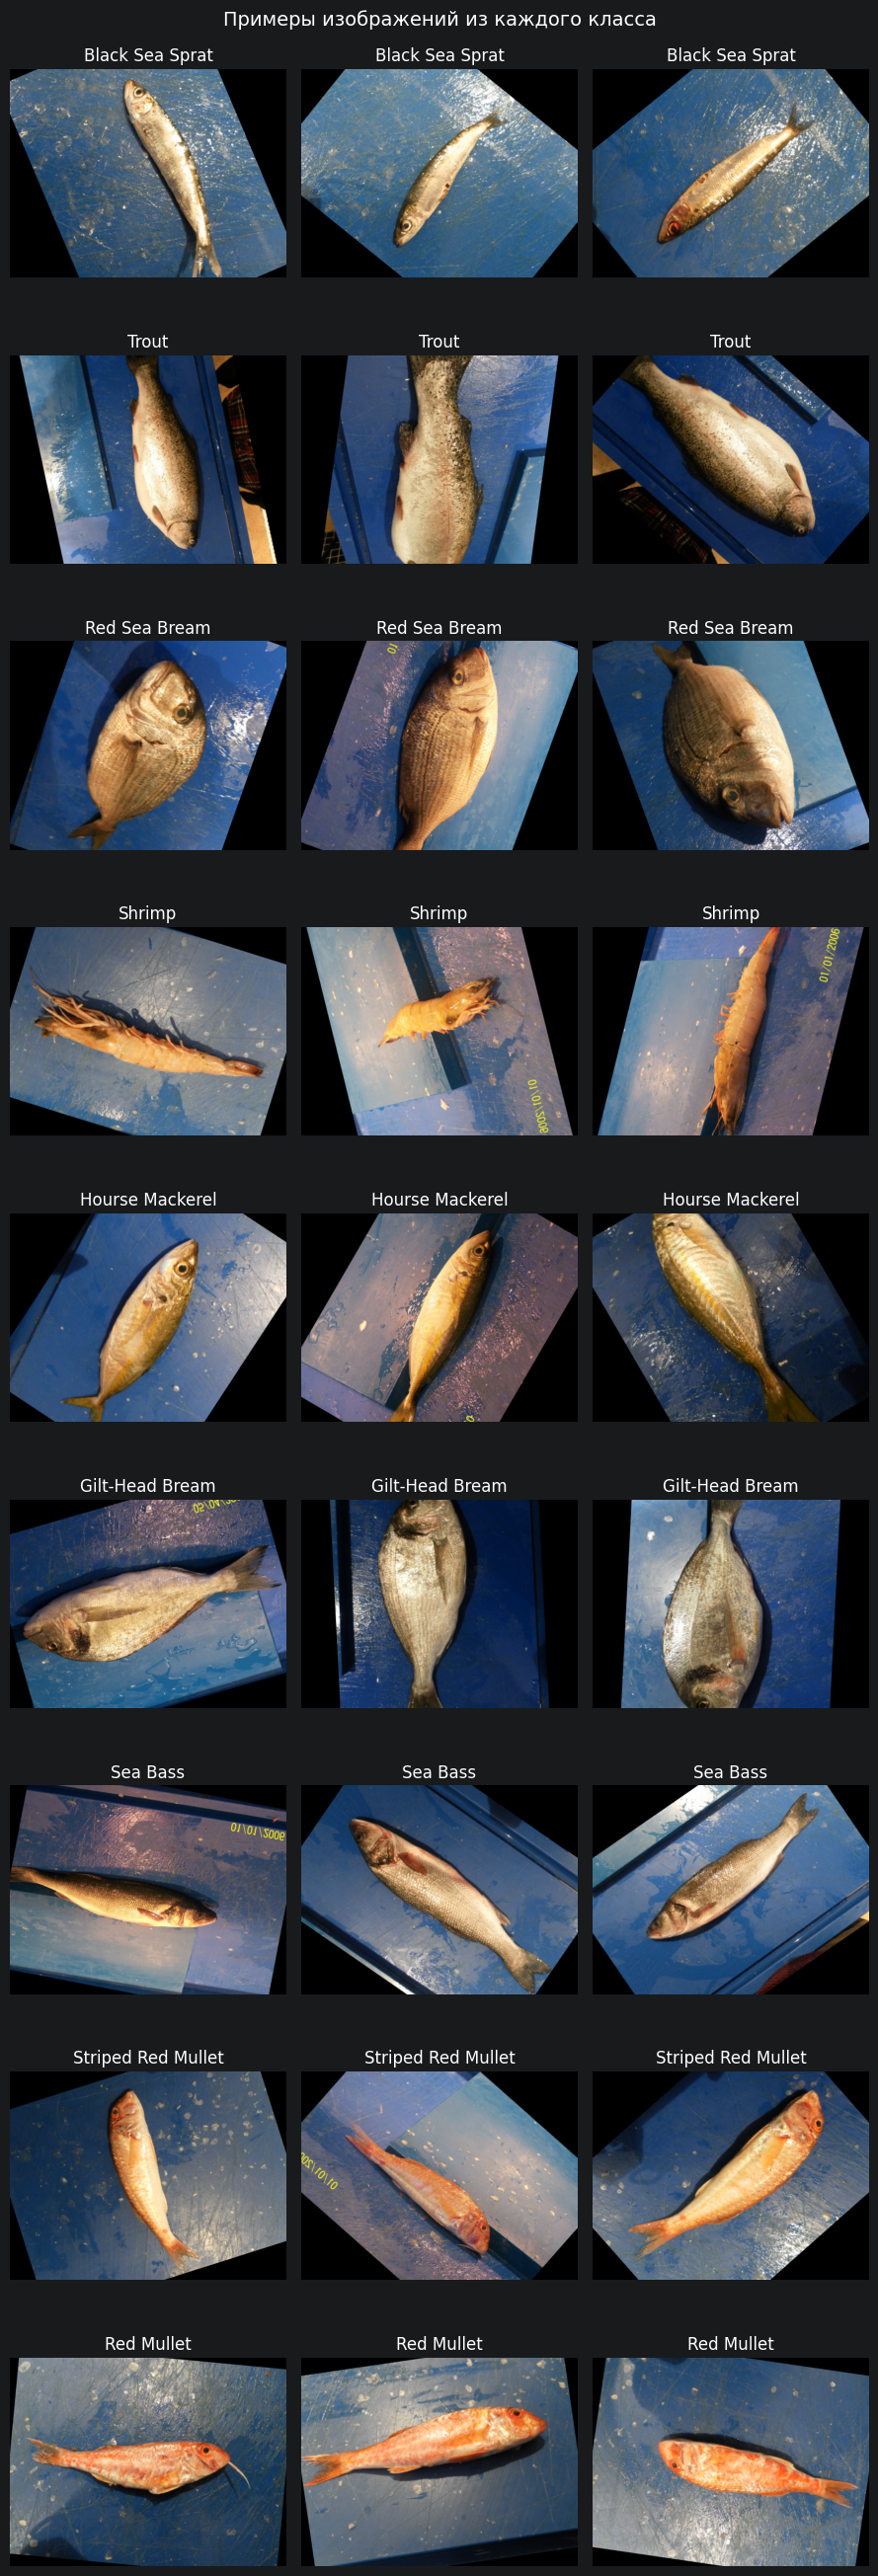

In [17]:
def plot_sample_image(image_paths, labels, classes, count_of_image=3):
    fig, axes = plt.subplots(len(classes), count_of_image, figsize=(count_of_image * 3, len(classes) * 3))
    for i, class_name in enumerate(classes):
        class_indices = [index for index, label in enumerate(labels) if label == class_name]
        sample_indices = class_indices[:count_of_image]

        for j, idx in enumerate(sample_indices):
            img = plt.imread(image_paths[idx])
            axes[i, j].imshow(img)
            axes[i, j].axis('off')
            axes[i, j].title.set_text(f"{class_name}")
            if j == 0:
                axes[i, j].set_ylabel(class_name, fontsize=10)
    plt.suptitle('Примеры изображений из каждого класса\n', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_sample_image(image_paths, labels, classes)

==> Проанализируем размеры изображений

In [18]:
img_shapes = []
for imgp in image_paths:
    img = plt.imread(imgp)
    img_shapes.append(img.shape)
print(set(img_shapes))

{(445, 590, 3)}


Все изображения имеют одинаковый размер, что не может не радовать

## Этап 3: предобработка данных

In [19]:
image_df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})
image_df.head()

,image_path,label
0,/home/gufort/.cache/kagglehub/datasets/crowww/...,Black Sea Sprat
1,/home/gufort/.cache/kagglehub/datasets/crowww/...,Black Sea Sprat
2,/home/gufort/.cache/kagglehub/datasets/crowww/...,Black Sea Sprat
3,/home/gufort/.cache/kagglehub/datasets/crowww/...,Black Sea Sprat
4,/home/gufort/.cache/kagglehub/datasets/crowww/...,Black Sea Sprat


In [20]:
label_encoder = LabelEncoder()
image_df['label'] = label_encoder.fit_transform(image_df['label'])
image_df = image_df.sample(frac=1, random_state=42)
image_df = image_df.reset_index(drop=True)
image_df.head(10)

,image_path,label
0,/home/gufort/.cache/kagglehub/datasets/crowww/...,7
1,/home/gufort/.cache/kagglehub/datasets/crowww/...,8
2,/home/gufort/.cache/kagglehub/datasets/crowww/...,0
3,/home/gufort/.cache/kagglehub/datasets/crowww/...,2
4,/home/gufort/.cache/kagglehub/datasets/crowww/...,3
5,/home/gufort/.cache/kagglehub/datasets/crowww/...,3
6,/home/gufort/.cache/kagglehub/datasets/crowww/...,1
7,/home/gufort/.cache/kagglehub/datasets/crowww/...,3
8,/home/gufort/.cache/kagglehub/datasets/crowww/...,6
9,/home/gufort/.cache/kagglehub/datasets/crowww/...,2


In [21]:
X = image_df['image_path']
Y = image_df['label']

In [22]:
feature_extractor = EfficientNetB0(
    weights='imagenet',      # Предобучена на ImageNet
    include_top=False,       # Убираем классификационную голову
    pooling='avg'            # Усредняем признаки по пространству
)

EfficientNetB0 требует фиксированный входной размер, обычно (224, 224, 3), а это квадрат, поэтому нужно преобразовать входные изображения. Мы будем делать это с помощью resize_with_pad. Если так не сделать, то на вход идут фото неестественные и вытянутые, а следовательно идет обучение неправильным пропорциям и так далее.

In [23]:
def load_and_preprocess_image(img_path, target_size):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Получаем исходные размеры
    h, w = img.shape[:2]
    target_w, target_h = target_size

    # Рассчитываем коэффициент масштабирования
    scale = min(target_w / w, target_h / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Изменяем размер с сохранением пропорций
    img_resized = cv2.resize(img, (new_w, new_h))

    # Создаем черное полотно нужного размера
    img_padded = np.zeros((target_h, target_w, 3), dtype=np.uint8)

    # Вычисляем отступы (padding)
    x_offset = (target_w - new_w) // 2
    y_offset = (target_h - new_h) // 2

    # Вставляем изображение в центр полотна
    img_padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img_resized

    return img_padded

img = load_and_preprocess_image(image_paths[0], target_size=(224, 224))
print(img.shape)

(224, 224, 3)


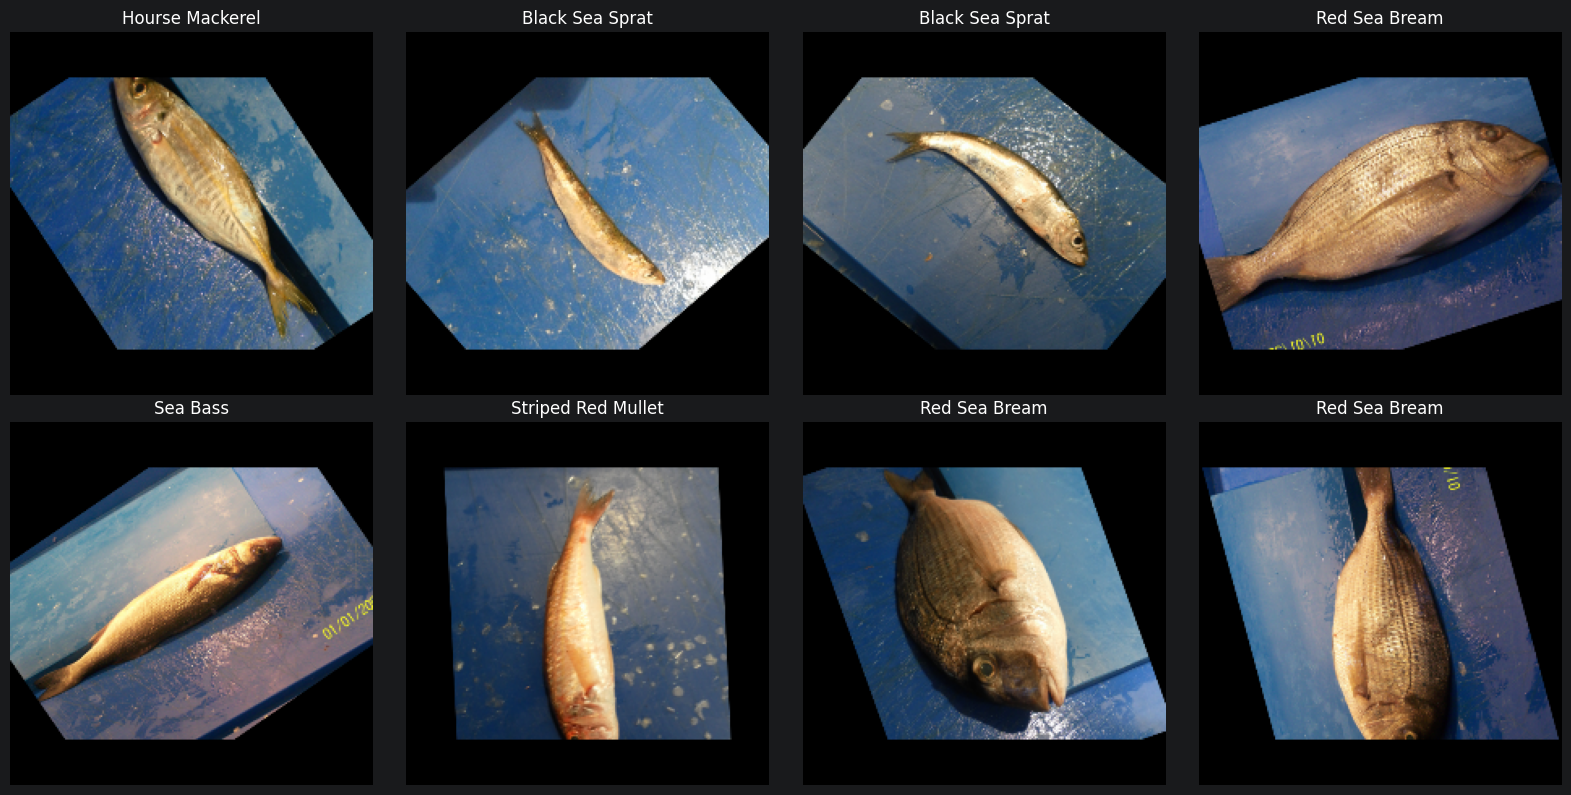

In [24]:
plt.figure(figsize=(16, 8))
i = 1
for x in list(image_df['image_path'].sample(8)):
    img = load_and_preprocess_image(x, (224, 224))
    plt.subplot(2, 4, i)
    plt.imshow(img)
    plt.axis("off")
    plt.title(x.split('/')[-2])
    i += 1
plt.tight_layout()
plt.show()

==> Функция для извлечения признаков из одного изображения

preprocess_input делает:
 1. Конвертирует RGB → BGR (для совместимости с ImageNet)
 2. Вычитает средние значения каналов
 3. Масштабирует определенным образом

Пример:

До: [0.5, 0.3, 0.2]

После: [-0.5, -0.7, -0.8]  (центрирование вокруг нуля)

In [59]:
def extract_features(img_path, target_size=(224, 224)):
    img = load_and_preprocess_image(img_path, target_size)

    # Добавляем batch dimension
    img_batch = np.expand_dims(img.astype('float32'), axis=0)
    # Предобработка для EfficientNetB0
    img_preprocessed = preprocess_input(img_batch.copy())
    # Извлечение признаков
    features = feature_extractor.predict(img_preprocessed, verbose=0) # [1, 224, 224, 3] -> [1, 1280], список характеристик
    return features.flatten()

In [62]:
features_list = []
i = 0
for img_path in image_df['image_path']:
    if i % 50 == 0:
        print(f"Обработано {i} из {len(image_paths)} изображений")
    features = extract_features(img_path)
    features_list.append(features)
    i += 1

X = np.array(features_list)
Y = image_df['label'].values

print(f"\nФорма матрицы признаков: {X.shape}")
print(f"Количество классов: {len(classes)}")

Обработано 0 из 9000 изображений
Обработано 50 из 9000 изображений
Обработано 100 из 9000 изображений
Обработано 150 из 9000 изображений
Обработано 200 из 9000 изображений
Обработано 250 из 9000 изображений
Обработано 300 из 9000 изображений
Обработано 350 из 9000 изображений
Обработано 400 из 9000 изображений
Обработано 450 из 9000 изображений
Обработано 500 из 9000 изображений
Обработано 550 из 9000 изображений
Обработано 600 из 9000 изображений
Обработано 650 из 9000 изображений
Обработано 700 из 9000 изображений
Обработано 750 из 9000 изображений
Обработано 800 из 9000 изображений
Обработано 850 из 9000 изображений
Обработано 900 из 9000 изображений
Обработано 950 из 9000 изображений
Обработано 1000 из 9000 изображений
Обработано 1050 из 9000 изображений
Обработано 1100 из 9000 изображений
Обработано 1150 из 9000 изображений
Обработано 1200 из 9000 изображений
Обработано 1250 из 9000 изображений
Обработано 1300 из 9000 изображений
Обработано 1350 из 9000 изображений
Обработано 1400

In [63]:
(X_train, X_test, Y_train, Y_test) = train_test_split(X, Y, test_size=0.2, random_state=42)

## Этап 4: использование нескольких алгоритмов МО

### ==> Logistic Regression

In [66]:
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=10000,
        random_state=42,
    ))
])
logreg.fit(X_train, Y_train)
pred = logreg.predict(X_test)
print('accuracy_score -> ', accuracy_score(Y_test, pred))

accuracy_score ->  1.0


In [65]:
param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 3.0],
    "clf__solver": ["lbfgs"],
}

search = RandomizedSearchCV(
    estimator=logreg,
    param_distributions=param_grid,
    n_iter=6,
    scoring="accuracy",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

search.fit(X_train, Y_train)

print("Best params:")
print(search.best_params_)

print("\nBest CV score:")
print(search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/gufort/PycharmProjects/JupyterProject/.venv/lib/python3.11/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=6. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END ......................clf__C=1.0, clf__solver=lbfgs; total time=   1.5s
[CV] END ......................clf__C=3.0, clf__solver=lbfgs; total time=   1.4s
[CV] END ......................clf__C=3.0, clf__solver=lbfgs; total time=   1.6s
[CV] END ......................clf__C=1.0, clf__solver=lbfgs; total time=   1.6s
[CV] END ......................clf__C=3.0, clf__solver=lbfgs; total time=   1.6s
[CV] END ......................clf__C=1.0, clf__solver=lbfgs; total time=   1.6s
[CV] END ......................clf__C=0.1, clf__solver=lbfgs; total time=   1.7s
[CV] END ......................clf__C=0.1, clf__solver=lbfgs; total time=   1.7s
[CV] END ......................clf__C=0.1, clf__solver=lbfgs; total time=   1.7s
[CV] END .....................clf__C=0.01, clf__solver=lbfgs; total time=   2.0s
[CV] END .....................clf__C=0.01, clf__solver=lbfgs; total time=   2.1s
[CV] END .....................clf__C=0.01, clf__solver=lbfgs; total time=   2.1s
Best params:
{'clf__solver':

In [67]:
best_logreg = search.best_estimator_

y_pred_logreg = best_logreg.predict(X_test)

train_accuracy = best_logreg.score(X_train, Y_train)
test_accuracy = best_logreg.score(X_test, Y_test)
print(f"Точность на тренировочных данных: {train_accuracy:.4f}")
print(f"Tочность на тестовых данных: {test_accuracy:.4f}")

Точность на тренировочных данных: 1.0000
Tочность на тестовых данных: 1.0000


In [68]:
report = classification_report(
        Y_test,
        y_pred_logreg,
        target_names=classes,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

report_df = pd.DataFrame(report).T
display(report_df)

,precision,recall,f1-score,support
Black Sea Sprat,1.0,1.0,1.0,196.0
Trout,1.0,1.0,1.0,207.0
Red Sea Bream,1.0,1.0,1.0,192.0
Shrimp,1.0,1.0,1.0,204.0
Hourse Mackerel,1.0,1.0,1.0,198.0
Gilt-Head Bream,1.0,1.0,1.0,187.0
Sea Bass,1.0,1.0,1.0,218.0
Striped Red Mullet,1.0,1.0,1.0,181.0
Red Mullet,1.0,1.0,1.0,217.0
accuracy,1.0,1.0,1.0,1.0


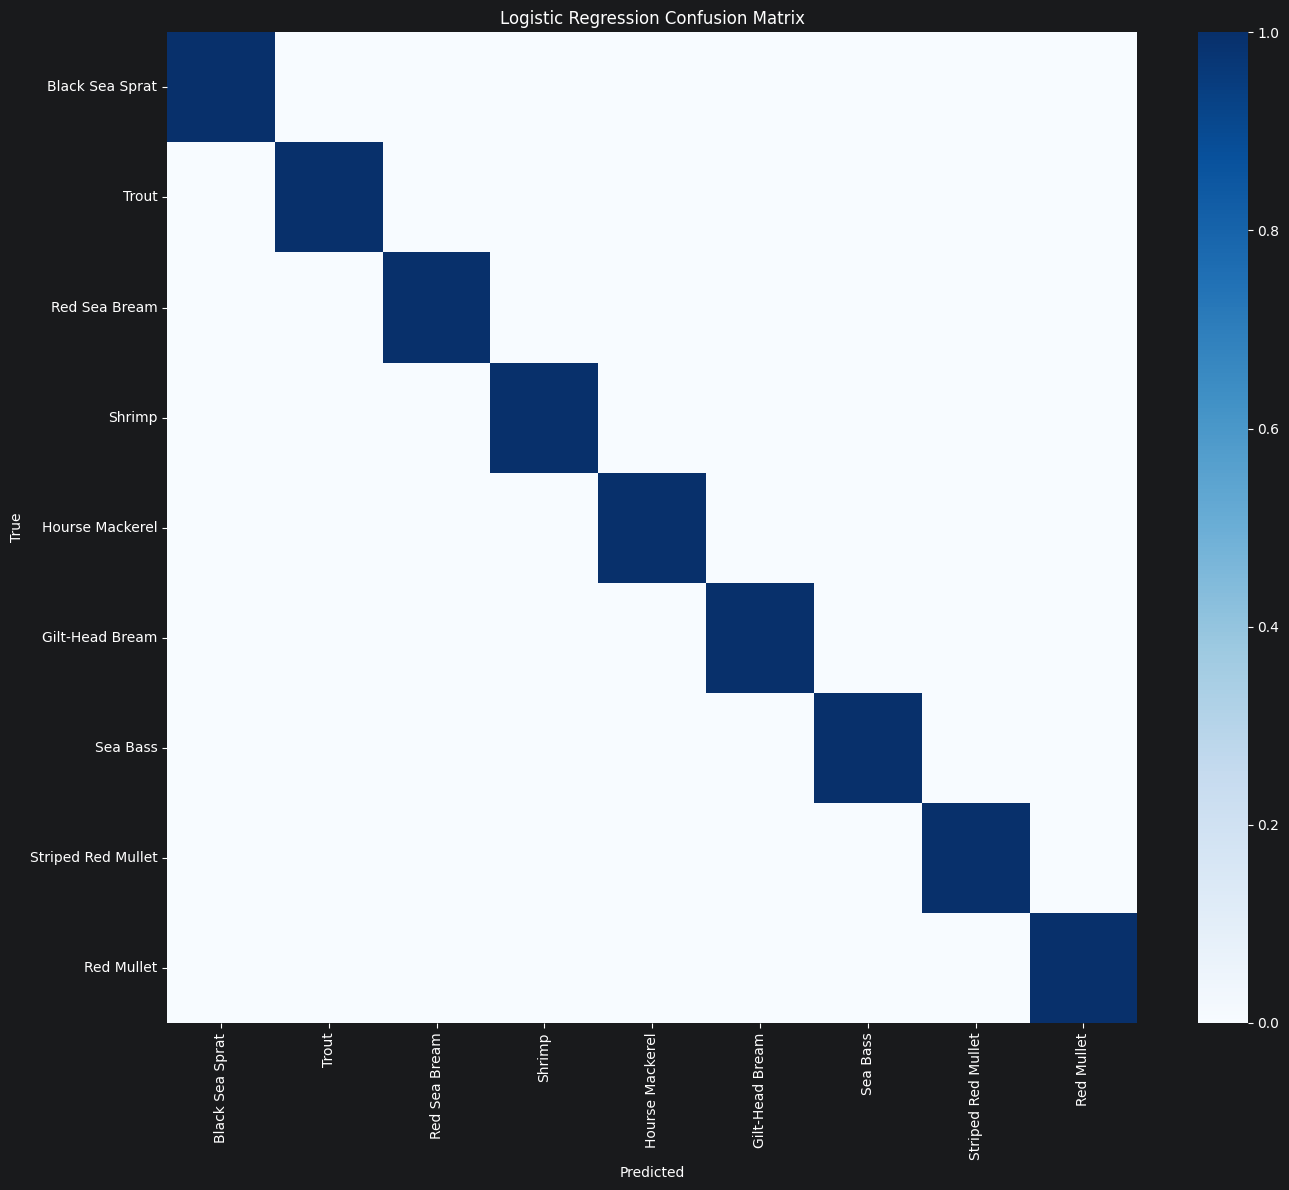

In [69]:
cm = confusion_matrix(Y_test, y_pred_logreg)
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

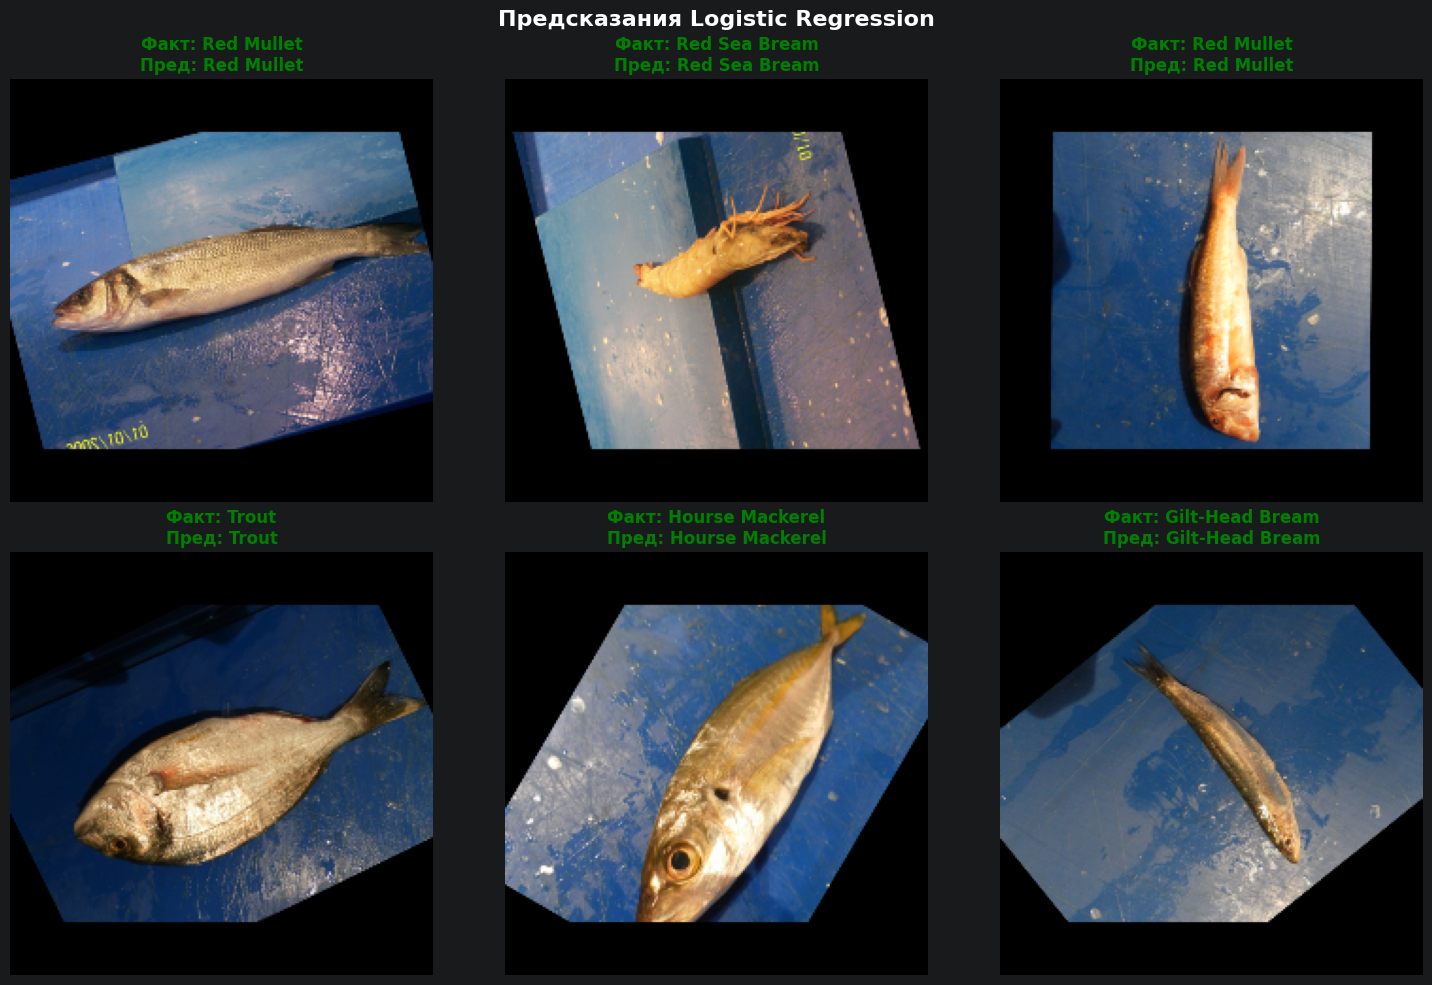

In [76]:
import random

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Берём 6 случайных индексов из тестовой выборки
sample_indices = random.sample(range(len(X_test)), 6)

for i, idx in enumerate(sample_indices):
    # Получаем путь к изображению и предсказание
    img_path = image_df['image_path'].values[len(X_train) + idx]  # из тестовой части
    true_label = label_encoder.inverse_transform([Y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_pred_logreg[idx]])[0]

    # Загружаем и отображаем изображение
    img = load_and_preprocess_image(img_path, (224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')

    correct = true_label == pred_label
    color = 'green' if correct else 'red'
    axes[i].set_title(
        f'Факт: {true_label}\nПред: {pred_label}',
        color=color,
        fontsize=12,
        fontweight='bold'
    )

plt.suptitle('Предсказания Logistic Regression', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### ==> RandomForest

In [70]:
rff = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)
rff.fit(X_train, Y_train)
pred = rff.predict(X_test)

In [71]:
df1 = pd.crosstab(Y_test, pred)
print('accuracy_score -> ', accuracy_score(Y_test, pred))
df1

accuracy_score ->  0.9988888888888889


col_0,0,1,2,3,4,5,6,7,8
row_0,,,,,,,,,
0,196,0,0,0,0,0,0,0,0
1,0,207,0,0,0,0,0,0,0
2,0,0,192,0,0,0,0,0,0
3,0,0,0,204,0,0,0,0,0
4,0,1,0,0,197,0,0,0,0
5,0,0,0,0,0,187,0,0,0
6,0,0,0,0,0,0,218,0,0
7,1,0,0,0,0,0,0,180,0
8,0,0,0,0,0,0,0,0,217


In [72]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, 40, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
}

rf_cv = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
    ),
    param_distributions=param_grid_rf,
    n_iter=8,
    cv=3,
    scoring="accuracy",
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

rf_cv.fit(X_train, Y_train)

print("Best params:")
print(rf_cv.best_params_)

print("\nBest score:")
print(rf_cv.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=  11.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=  13.8s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=  14.4s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=  15.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=  15.0s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=  15.1s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   9.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=200;

In [77]:
best_forest = RandomForestClassifier(**rf_cv.best_params_, random_state=42)
best_forest.fit(X_train, Y_train)
y_pred_rf = best_forest.predict(X_test)

train_accuracy = best_forest.score(X_train, Y_train)
test_accuracy = best_forest.score(X_test, Y_test)

print(f"Точность на тренировочных данных: {train_accuracy:.4f}")
print(f"Tочность на тестовых данных: {test_accuracy:.4f}")

Точность на тренировочных данных: 1.0000
Tочность на тестовых данных: 0.9994


In [84]:
report_rf = classification_report(
        Y_test,
        y_pred_rf,
        target_names=classes,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

report_rf_df = pd.DataFrame(report_rf).T
display(report_rf_df)

,precision,recall,f1-score,support
Black Sea Sprat,1.000000,1.000000,1.000000,196.000000
Trout,0.995192,1.000000,0.997590,207.000000
Red Sea Bream,1.000000,1.000000,1.000000,192.000000
Shrimp,1.000000,1.000000,1.000000,204.000000
Hourse Mackerel,1.000000,0.994949,0.997468,198.000000
Gilt-Head Bream,1.000000,1.000000,1.000000,187.000000
Sea Bass,1.000000,1.000000,1.000000,218.000000
Striped Red Mullet,1.000000,1.000000,1.000000,181.000000
Red Mullet,1.000000,1.000000,1.000000,217.000000
accuracy,0.999444,0.999444,0.999444,0.999444


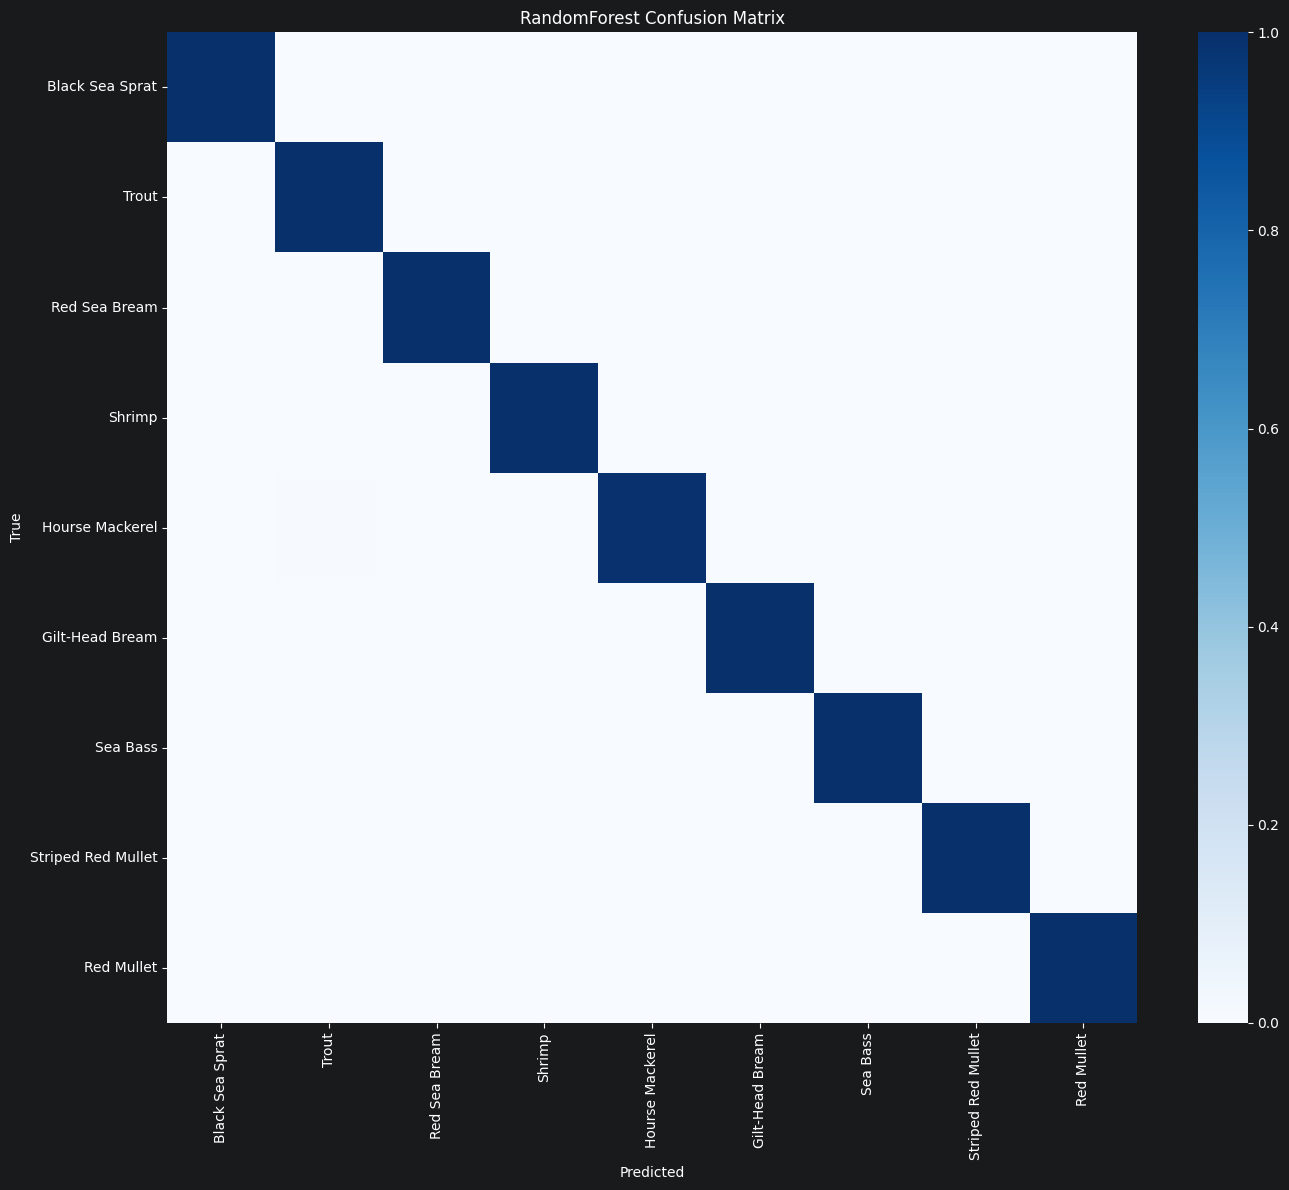

In [85]:
cm = confusion_matrix(Y_test, y_pred_rf)
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RandomForest Confusion Matrix")

plt.tight_layout()
plt.show()

### ==> SVC

In [86]:
svc = SVC(random_state=42, probability=True, max_iter = 10000)

svc.fit(X_train, Y_train)
pred = svc.predict(X_test)
print('accuracy_score -> ', accuracy_score(Y_test, pred))

accuracy_score ->  1.0


In [83]:
svc_param_grid = {
    'C': [0.1, 1, 2],
    'kernel': ['linear', 'rbf']
}

svc_cv = GridSearchCV(svc, svc_param_grid, cv=3, scoring="accuracy", verbose=2, n_jobs=-1)
svc_cv.fit(X_train, Y_train)

print("Best params:")
print(svc_cv.best_params_)

print("\nBest score:")
print(svc_cv.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .................................C=1, kernel=linear; total time=  45.4s
[CV] END ...............................C=0.1, kernel=linear; total time=  45.7s
[CV] END .................................C=1, kernel=linear; total time=  45.4s
[CV] END ...............................C=0.1, kernel=linear; total time=  46.5s
[CV] END .................................C=1, kernel=linear; total time=  47.3s
[CV] END ...............................C=0.1, kernel=linear; total time=  47.7s
[CV] END .................................C=2, kernel=linear; total time=  43.2s
[CV] END .................................C=2, kernel=linear; total time=  43.4s
[CV] END .................................C=2, kernel=linear; total time=  44.3s
[CV] END ....................................C=1, kernel=rbf; total time= 1.5min
[CV] END ....................................C=1, kernel=rbf; total time= 1.5min
[CV] END ....................................C=1,

In [87]:
best_svc = svc_cv.best_estimator_
best_svc.fit(X_train, Y_train)
y_pred_svc = best_svc.predict(X_test)

train_accuracy = best_svc.score(X_train, Y_train)
test_accuracy = best_svc.score(X_test, Y_test)

print(f"Точность на тренировочных данных: {train_accuracy:.4f}")
print(f"Tочность на тестовых данных: {test_accuracy:.4f}")

Точность на тренировочных данных: 1.0000
Tочность на тестовых данных: 1.0000


In [88]:
report_svc = classification_report(
        Y_test,
        y_pred_svc,
        target_names=classes,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

report_svc_df = pd.DataFrame(report_rf).T
display(report_svc_df)

,precision,recall,f1-score,support
Black Sea Sprat,1.000000,1.000000,1.000000,196.000000
Trout,0.995192,1.000000,0.997590,207.000000
Red Sea Bream,1.000000,1.000000,1.000000,192.000000
Shrimp,1.000000,1.000000,1.000000,204.000000
Hourse Mackerel,1.000000,0.994949,0.997468,198.000000
Gilt-Head Bream,1.000000,1.000000,1.000000,187.000000
Sea Bass,1.000000,1.000000,1.000000,218.000000
Striped Red Mullet,1.000000,1.000000,1.000000,181.000000
Red Mullet,1.000000,1.000000,1.000000,217.000000
accuracy,0.999444,0.999444,0.999444,0.999444


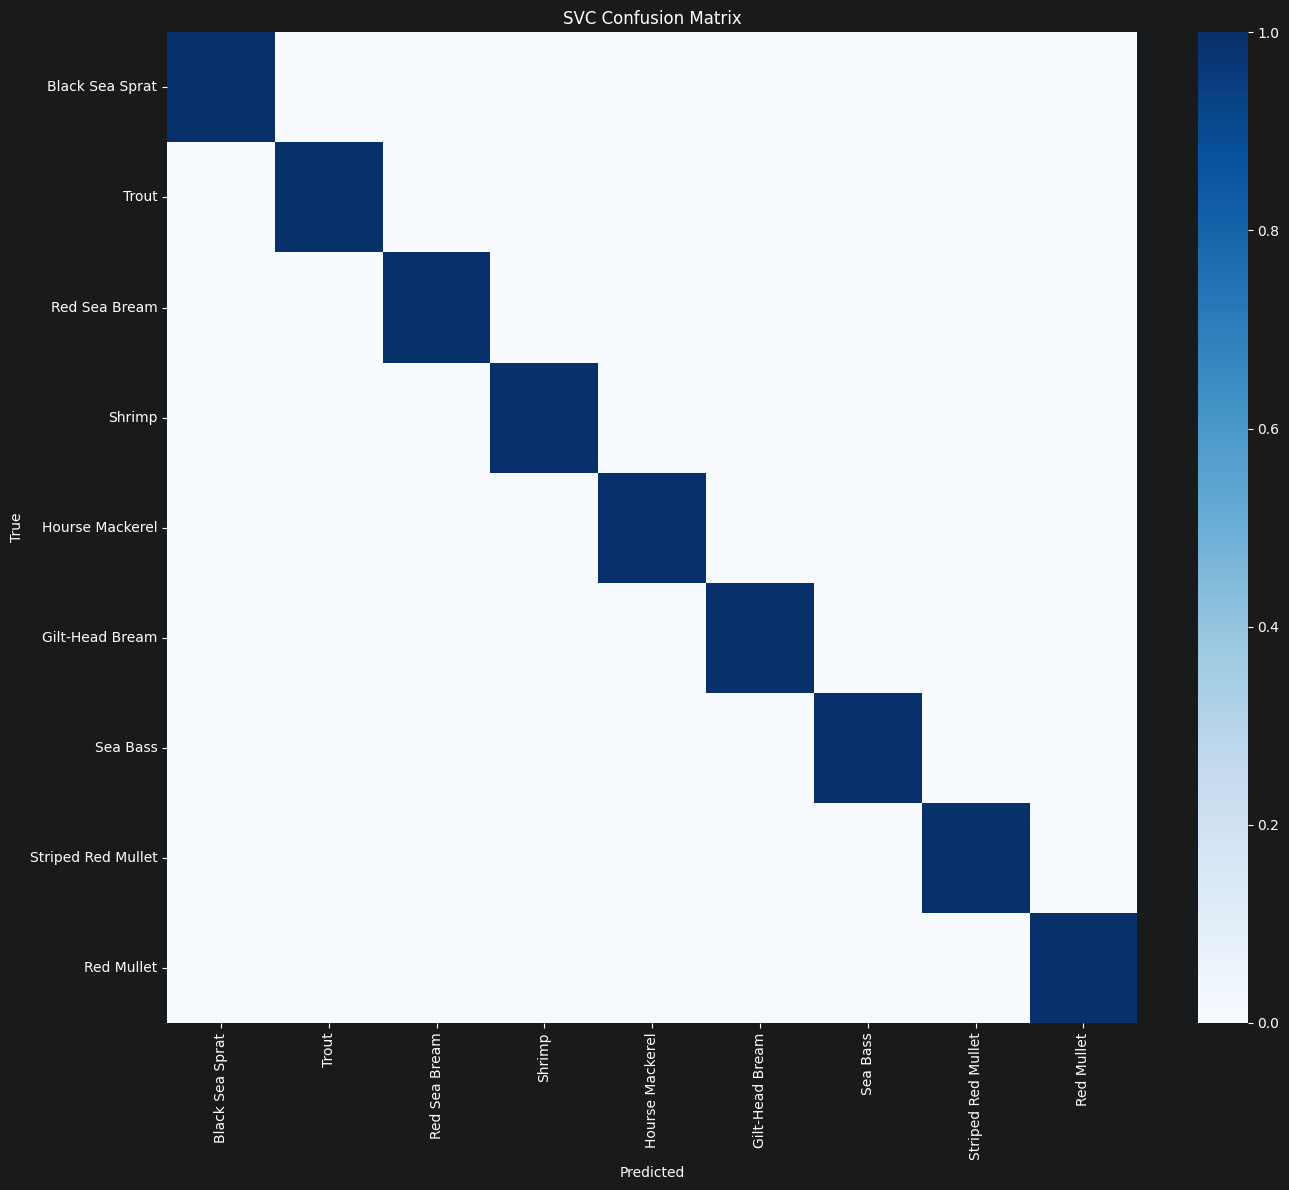

In [89]:
cm = confusion_matrix(Y_test, y_pred_svc)
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVC Confusion Matrix")

plt.tight_layout()
plt.show()

### ==> GradientBoosting

In [90]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(random_state=42)
gb.fit(X_train, Y_train)

pred = gb.predict(X_test)
print('accuracy_score -> ', accuracy_score(Y_test, pred))

accuracy_score ->  1.0


In [91]:
gb_param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_iter': [50, 100], # это аналог n_estimators
    'max_depth': [3, 5]
}

gb_rs = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_param_grid,
    n_iter=6,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
gb_rs.fit(X_train, Y_train)

print("Best params:")
print(gb_rs.best_params_)

print("\nBest score:")
print(gb_rs.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params:
{'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.1}

Best score:
0.9987500000000001


In [92]:
best_gb = gb_rs.best_estimator_
best_gb.fit(X_train, Y_train)
y_pred_gb = best_gb.predict(X_test)

train_accuracy = best_gb.score(X_train, Y_train)
test_accuracy = best_gb.score(X_test, Y_test)

print(f"Точность на тренировочных данных: {train_accuracy:.4f}")
print(f"Tочность на тестовых данных: {test_accuracy:.4f}")

Точность на тренировочных данных: 1.0000
Tочность на тестовых данных: 1.0000


In [93]:
report_gb = classification_report(
        Y_test,
        y_pred_gb,
        target_names=classes,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

report_gb_df = pd.DataFrame(report_gb).T
display(report_gb_df)

,precision,recall,f1-score,support
Black Sea Sprat,1.0,1.0,1.0,196.0
Trout,1.0,1.0,1.0,207.0
Red Sea Bream,1.0,1.0,1.0,192.0
Shrimp,1.0,1.0,1.0,204.0
Hourse Mackerel,1.0,1.0,1.0,198.0
Gilt-Head Bream,1.0,1.0,1.0,187.0
Sea Bass,1.0,1.0,1.0,218.0
Striped Red Mullet,1.0,1.0,1.0,181.0
Red Mullet,1.0,1.0,1.0,217.0
accuracy,1.0,1.0,1.0,1.0


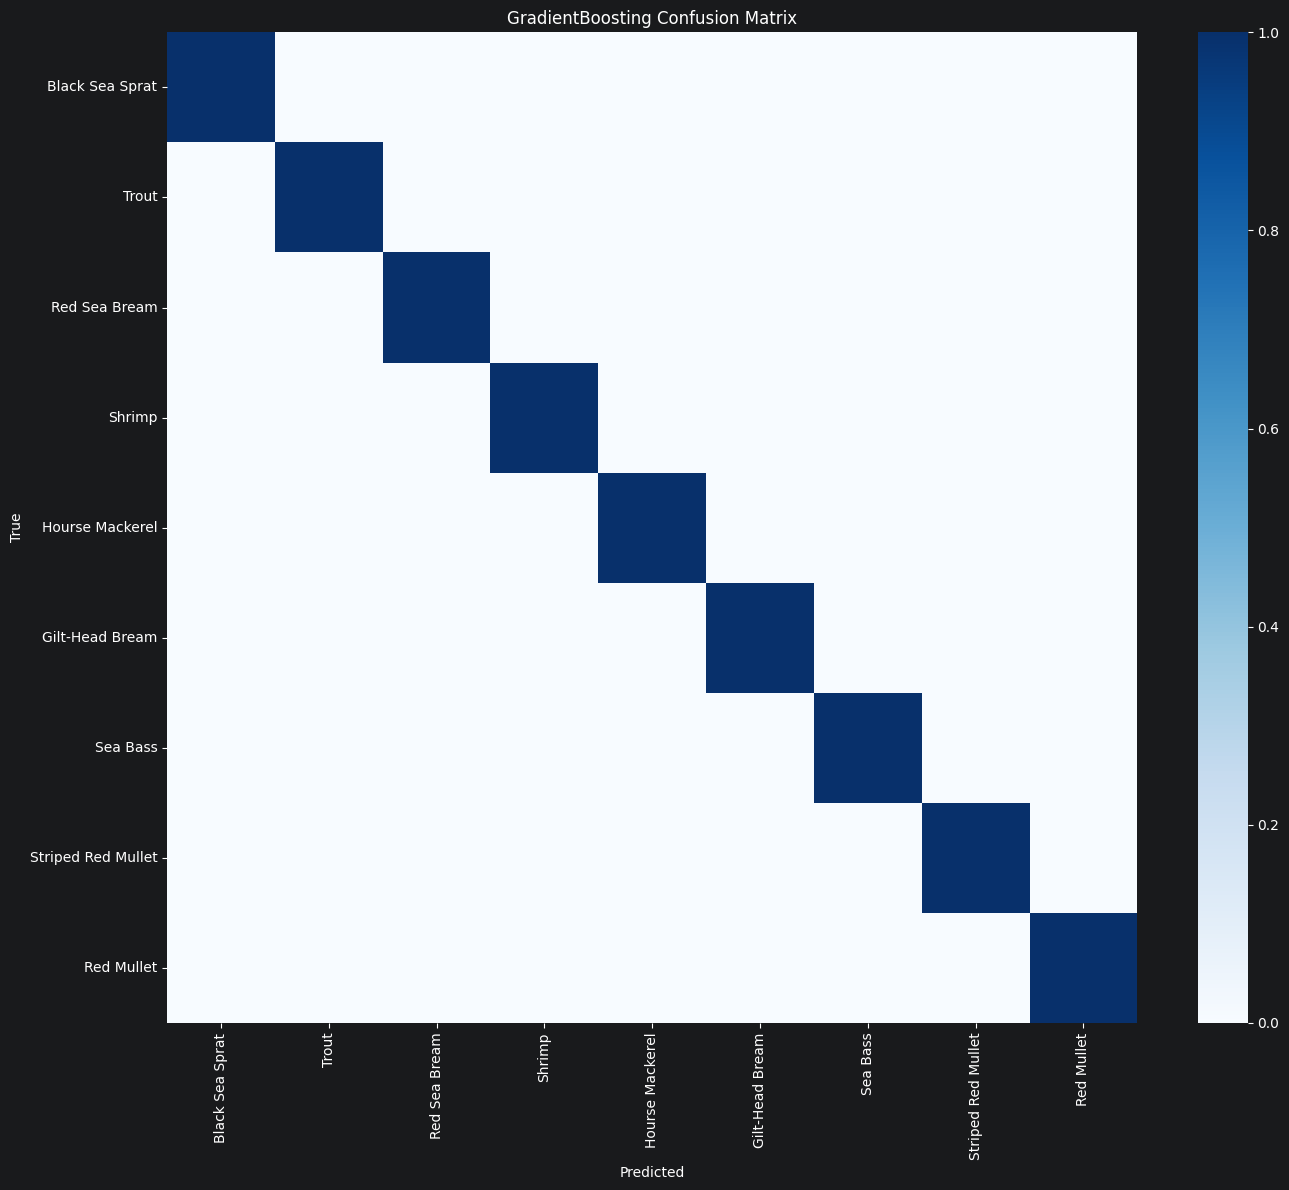

In [94]:
cm = confusion_matrix(Y_test, y_pred_gb)
cm_norm = cm.astype("float") / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GradientBoosting Confusion Matrix")

plt.tight_layout()
plt.show()

### ==> VoatingClassifer

In [95]:
from sklearn.ensemble import VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_forest),
        ('gb', best_gb),
        ('svc', best_svc),
        ('lg', best_logreg)
    ],
    voting='soft'
)

voting_clf.fit(X_train, Y_train)
y_pred_voting = voting_clf.predict(X_test)

train_accuracy = voting_clf.score(X_train, Y_train)
test_accuracy = voting_clf.score(X_test, Y_test)

print(f"Точность на тренировочных данных: {train_accuracy:.4f}")
print(f"Tочность на тестовых данных: {test_accuracy:.4f}")

Точность на тренировочных данных: 1.0000
Tочность на тестовых данных: 1.0000
